Este cuaderno es la versión interactiva del capítulo 7 del libro, y está orientada a Colab. Contiene únicamente el código Python; para las explicaciones teóricas y el código R consulta el libro en:

[https://juanriera.github.io/master-queseria/](https://juanriera.github.io/master-queseria/)

Para utilizar los datos que se utilizan en el cuaderno, descarga el CSV de ejemplo y súbelo al espacio de trabajo de Colab.

[Descargar los datos `camembert.csv`](https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/camembert.csv)

En los capítulos anteriores hemos aprendido a describir datos mediante gráficos y estadísticos. Ahora vamos a aplicar todo lo aprendido a un caso real: el análisis exploratorio de una temporada completa de fabricación de queso camembert. Los datos corresponden a los análisis de control de calidad realizados durante el año 2020 en una quesería, con una o dos fabricaciones diarias a lo largo de los días laborables. El dataset contiene 211 observaciones y seis variables:

- `est`: extracto seco total (%)
- `mg`: materia grasa (%)
- `ph`: pH del queso
- `cloruros`: contenido en cloruros (%)
- `coliformes`: recuento de bacterias coliformes (ufc/g)
- `fabricacion`: número de fabricación del día (1 o 2)

[Descargar los datos `camembert.csv`](https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/camembert.csv)

## Flujo de trabajo

Como vimos en el capítulo 2, es muy conveniente establecer un flujo de trabajo regular, de forma que cada etapa del análisis se apoye en las anteriores:

![](imagenes/080/data-science-explore.svg)

Vamos a ir desarrollando este flujo paso a paso.

## Importar los datos

Cargamos el fichero desde GitHub. Si has descargado el fichero en tu ordenador, puedes adaptar la ruta de lectura según vimos en el capítulo anterior.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url_datos = (
    "https://raw.githubusercontent.com/"
    "juanriera/master-queseria/master/"
    "datos/camembert.csv"
)

try:
    df = pd.read_csv(url_datos,
                     decimal=",",
                     sep=';',
                     encoding='ISO-8859-1')
    print("Archivo cargado correctamente.")
    print(f"Dimensiones: {df.shape}")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

Archivo cargado correctamente.
Dimensiones: (211, 7)


Inspeccionamos las primeras filas y la estructura del dataframe:

In [2]:
df.head()

,fecha,fabricacion,est,mg,ph,cloruros,coliformes
0,11/01/2020,1,46.68,24.0,4.85,1.50,80.0
1,12/01/2020,1,48.09,25.0,4.67,1.61,0.0
2,13/01/2020,1,45.97,24.0,4.71,1.48,9200.0
3,14/01/2020,1,46.24,23.5,4.78,1.69,20.0
4,15/01/2020,1,45.81,23.0,4.77,1.56,150.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fecha        211 non-null    object 
 1   fabricacion  211 non-null    int64  
 2   est          211 non-null    float64
 3   mg           211 non-null    float64
 4   ph           211 non-null    float64
 5   cloruros     211 non-null    float64
 6   coliformes   210 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 11.7+ KB


La columna `fecha` aparece como tipo texto. La convertimos a formato fecha:

In [4]:
df['fecha'] = pd.to_datetime(
    df['fecha'],
    format='%d/%m/%Y',
    errors='coerce'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   fecha        211 non-null    datetime64[ns]
 1   fabricacion  211 non-null    int64         
 2   est          211 non-null    float64       
 3   mg           211 non-null    float64       
 4   ph           211 non-null    float64       
 5   cloruros     211 non-null    float64       
 6   coliformes   210 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 11.7 KB


## Verificar los datos

Antes de analizar, verificamos que los valores son plausibles. Calculamos un resumen estadístico de todas las variables:

In [5]:
df.describe().round(2)

,fecha,fabricacion,est,mg,ph,cloruros,coliformes
count,211,211.00,211.00,211.00,211.00,211.00,210.00
mean,2020-06-30 14:06:15.355450112,1.05,46.64,23.73,4.68,1.45,650.88
min,2020-01-11 00:00:00,1.00,42.92,21.50,4.35,-1.00,0.00
25%,2020-03-21 12:00:00,1.00,45.61,23.00,4.63,1.35,0.00
50%,2020-07-04 00:00:00,1.00,46.60,23.50,4.68,1.46,10.00
75%,2020-10-05 12:00:00,1.00,47.47,24.50,4.74,1.56,190.00
max,2020-12-29 00:00:00,2.00,52.61,28.00,4.99,1.89,20200.00
std,NaN,0.22,1.45,0.94,0.08,0.23,2194.15


Ya en este primer resumen aparecen varias señales que merecen atención: el mínimo de `cloruros` es -1, lo que es físicamente imposible; el máximo de `est` es 52,61, claramente alejado del resto; y el rango de `coliformes` va de 0 a 20.200, con una dispersión enorme. Analizaremos cada variable con detalle en la sección siguiente.

## Análisis variable a variable

### Extracto seco total (`est`)

Comenzamos con la variable principal. En el capítulo 6 usamos el histograma y el boxplot para estudiar la forma de los datos; aquí los aplicamos directamente al caso real.

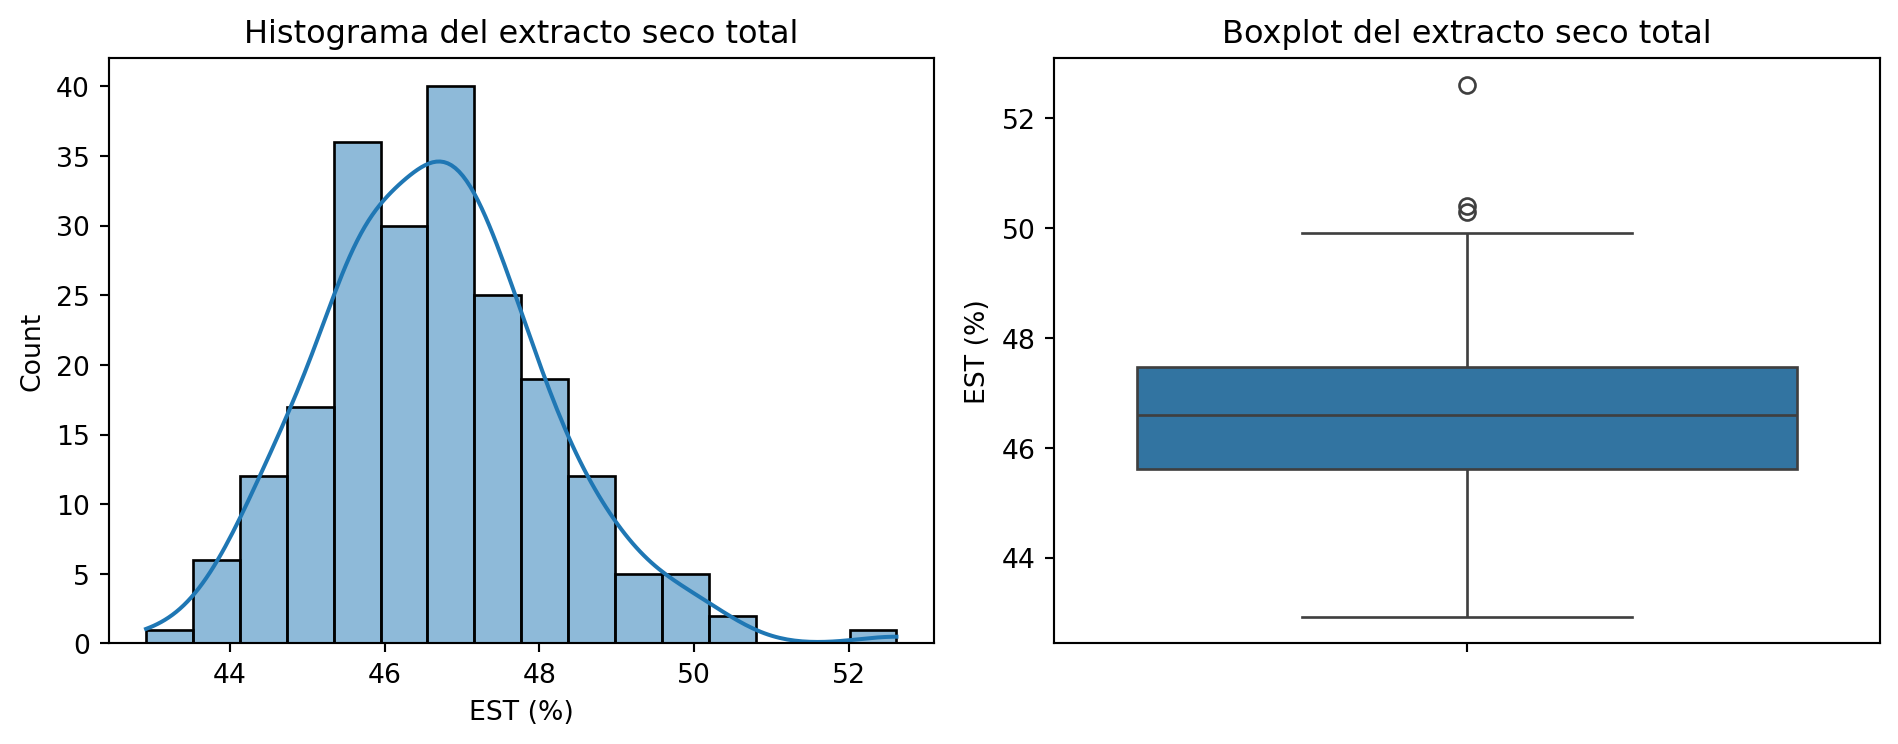

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['est'], kde=True, ax=ax1)
ax1.set_title("Histograma del extracto seco total")
ax1.set_xlabel("EST (%)")

sns.boxplot(y=df['est'], ax=ax2)
ax2.set_title("Boxplot del extracto seco total")
ax2.set_ylabel("EST (%)")

plt.tight_layout()
plt.show()

El histograma muestra una distribución aproximadamente simétrica en torno a 46-47%, pero con una cola hacia la derecha y una barra aislada en torno a 52%. La curva de densidad muestra una pequeña elevación en ese extremo que no debería estar ahí si la distribución fuese una campana de Gauss limpia. El boxplot confirma la presencia de varios valores atípicos por encima de 50%.

¿Son errores o valores reales? Para responderlo necesitamos contexto temporal.

### Serie temporal del extracto seco

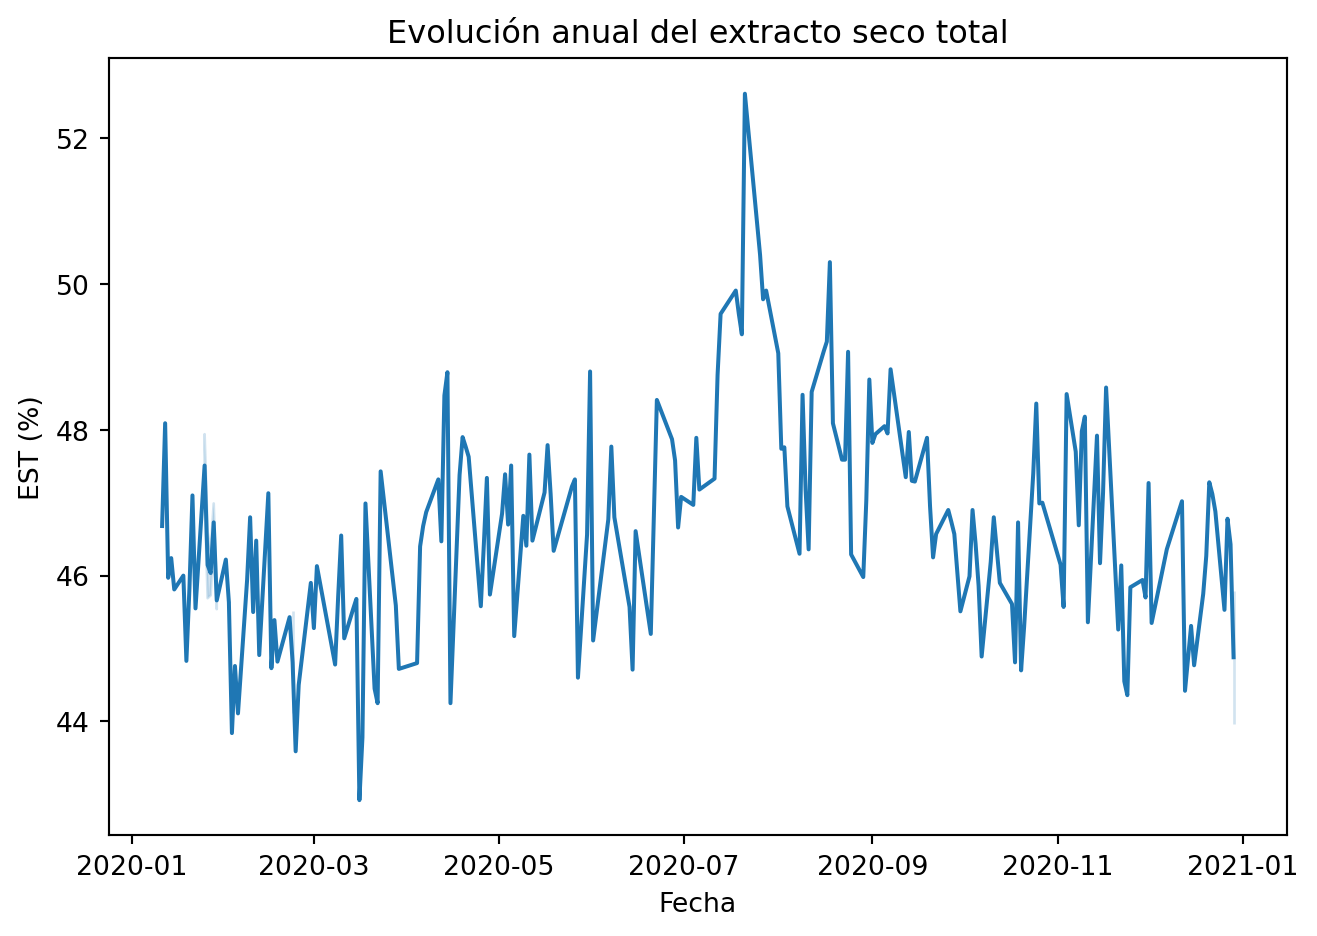

In [7]:
df['fecha_index'] = pd.DatetimeIndex(df.fecha).normalize()
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

sns.lineplot(data=df, x='fecha', y='est')
plt.title("Evolución anual del extracto seco total")
plt.xlabel("Fecha")
plt.ylabel("EST (%)")
plt.tight_layout()
plt.show()

La serie temporal revela lo que el histograma no podía mostrar: los valores altos se concentran en los meses de verano, especialmente julio y agosto. El valor máximo de 52,61% corresponde al 21 de julio. Esto cambia completamente la interpretación: los valores por encima de 50% no son errores aislados sino parte de una desviación estacional sostenida durante varias semanas. La forma del histograma que parecía simplemente asimétrica era en realidad la mezcla de dos momentos del año con comportamientos distintos: exactamente el caso de distribución bimodal que estudiamos en el capítulo 6.

Visualizamos la media semanal y su dispersión para ver la evolución con más claridad:

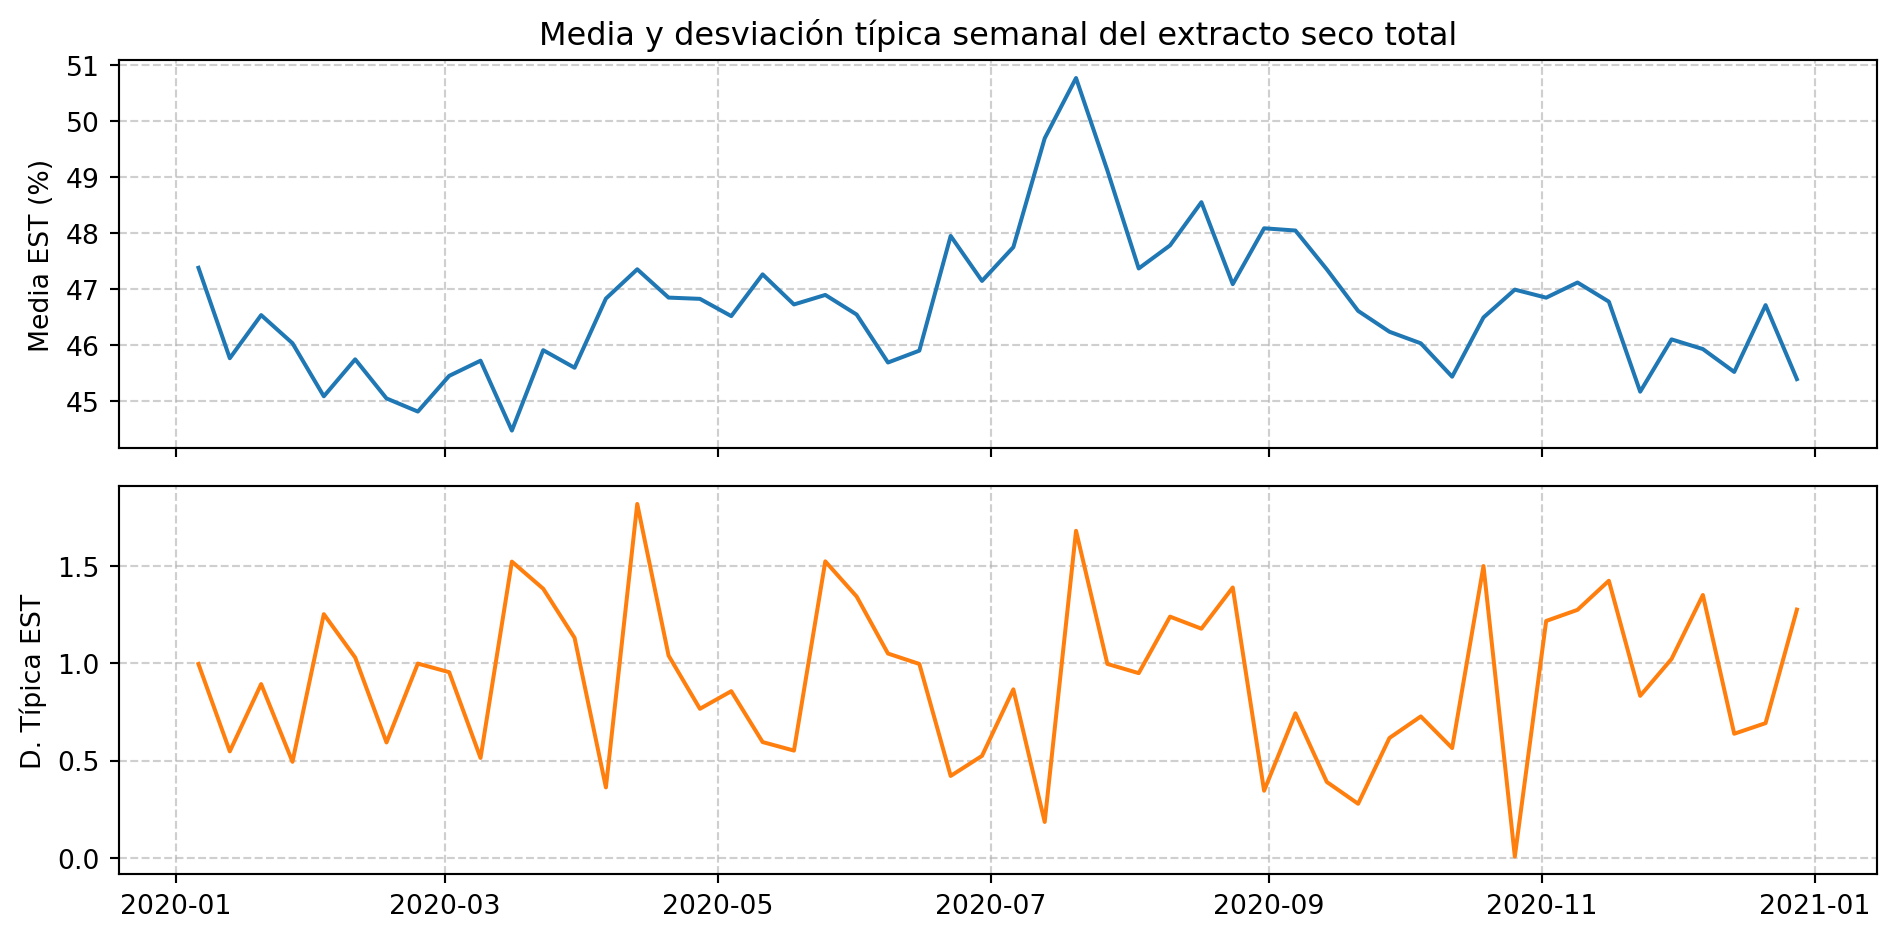

In [8]:
media_semanal = df["est"].resample(
    'W-MON', label='left', closed='left').mean()
dt_semanal = df["est"].resample(
    'W-MON', label='left', closed='left').std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax1.plot(media_semanal, color='tab:blue')
ax1.set_title("Media y desviación típica semanal del extracto seco total")
ax1.set_ylabel("Media EST (%)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.tick_params(labelbottom=False)

ax2.plot(dt_semanal, color='tab:orange')
ax2.set_ylabel("D. Típica EST")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Boxplot mensual del extracto seco

El boxplot por meses permite ver si los valores de julio son atípicos dentro de su propio contexto mensual:

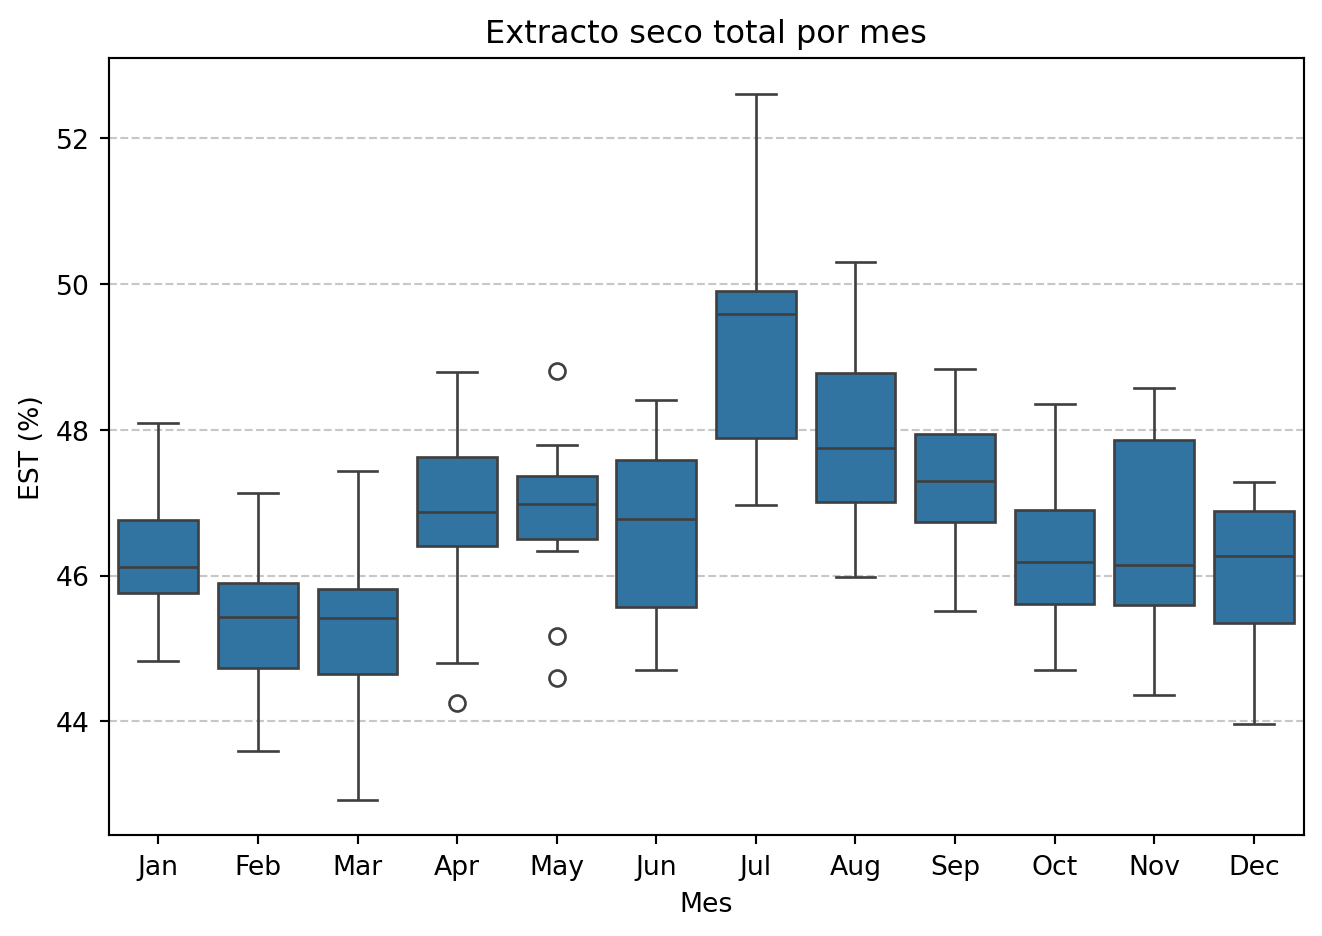

In [9]:
import calendar
df_plot_est = df.copy()
df_plot_est['mes_abreviado'] = df_plot_est.index.strftime('%b')
meses_orden = [calendar.month_abbr[i] for i in range(1, 13)]
df_plot_est['mes_abreviado'] = pd.Categorical(
    df_plot_est['mes_abreviado'],
    categories=meses_orden,
    ordered=True
)

sns.boxplot(x='mes_abreviado', y='est', data=df_plot_est)
plt.title("Extracto seco total por mes")
plt.xlabel("Mes")
plt.ylabel("EST (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Ahora la imagen es completamente distinta. En julio prácticamente todos los valores son altos: la mediana mensual de julio es la más alta del año, y el valor de 52,61% no es tan extremo dentro de ese mes. En cambio, en mayo aparece una dispersión muy baja seguida de un salto brusco en junio, que merece atención. Los meses de otoño e invierno muestran una distribución mucho más estable y centrada.

### Materia grasa (`mg`)

Aplicamos el mismo análisis a la materia grasa:

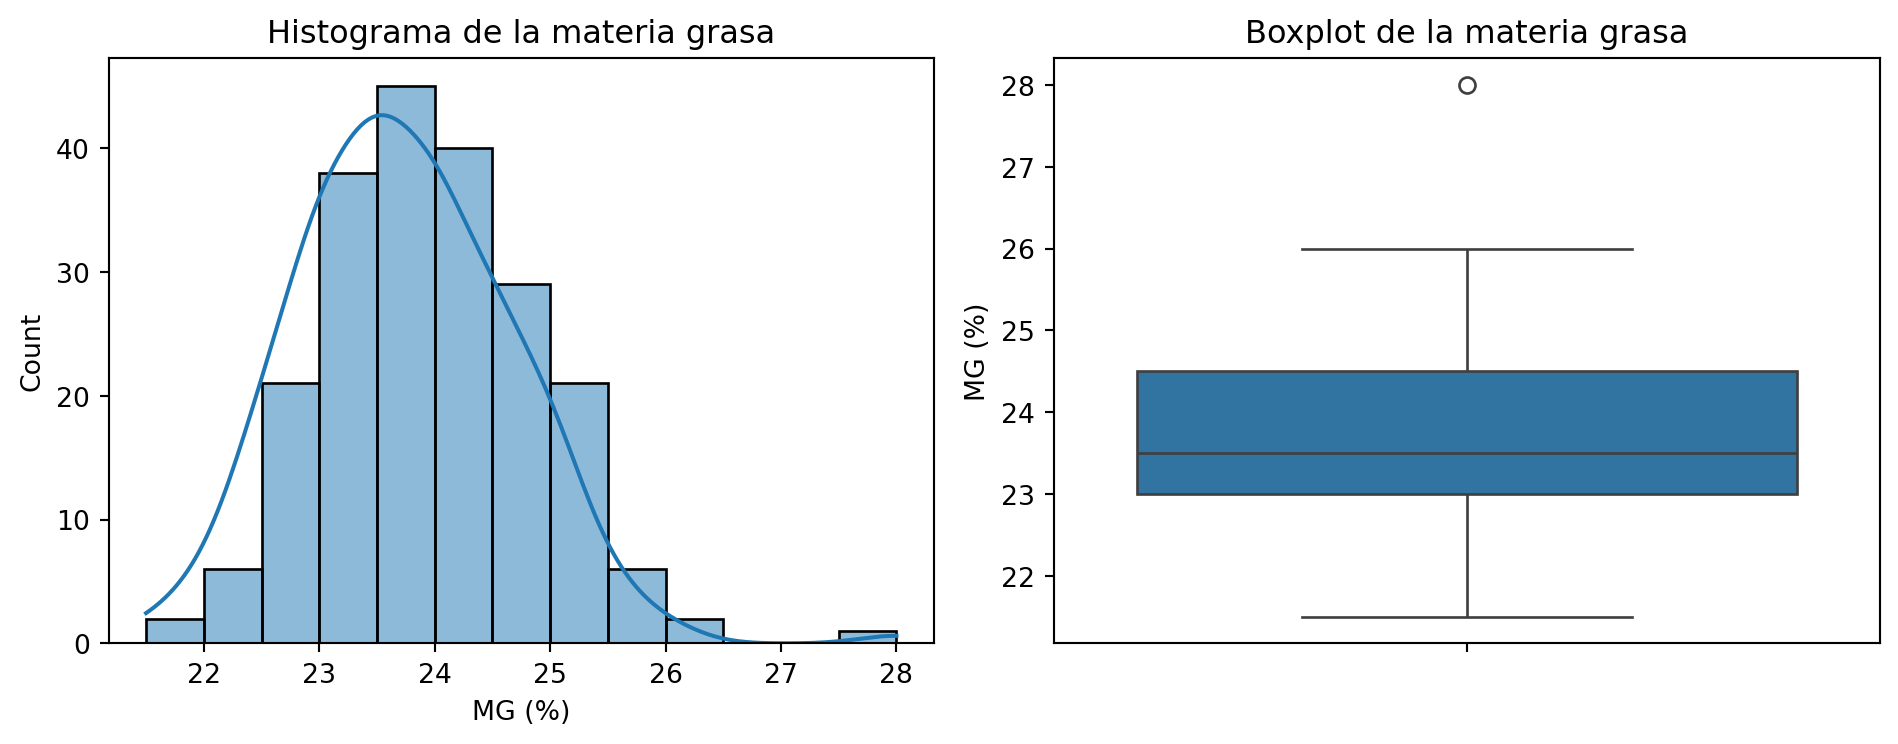

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['mg'], kde=True, ax=ax1)
ax1.set_title("Histograma de la materia grasa")
ax1.set_xlabel("MG (%)")

sns.boxplot(y=df['mg'], ax=ax2)
ax2.set_title("Boxplot de la materia grasa")
ax2.set_ylabel("MG (%)")

plt.tight_layout()
plt.show()

El histograma de la materia grasa muestra una distribución aproximadamente simétrica centrada en torno a 23,5%, pero el boxplot señala un valor atípico alto claramente separado del resto. Ese valor es 28%, registrado el 26 de enero, y es el único por encima de 27%. Puede ser un error de estandarización en el arranque del año, cuando la composición de la leche de invierno es más rica en grasa. Lo analizamos en la serie temporal:

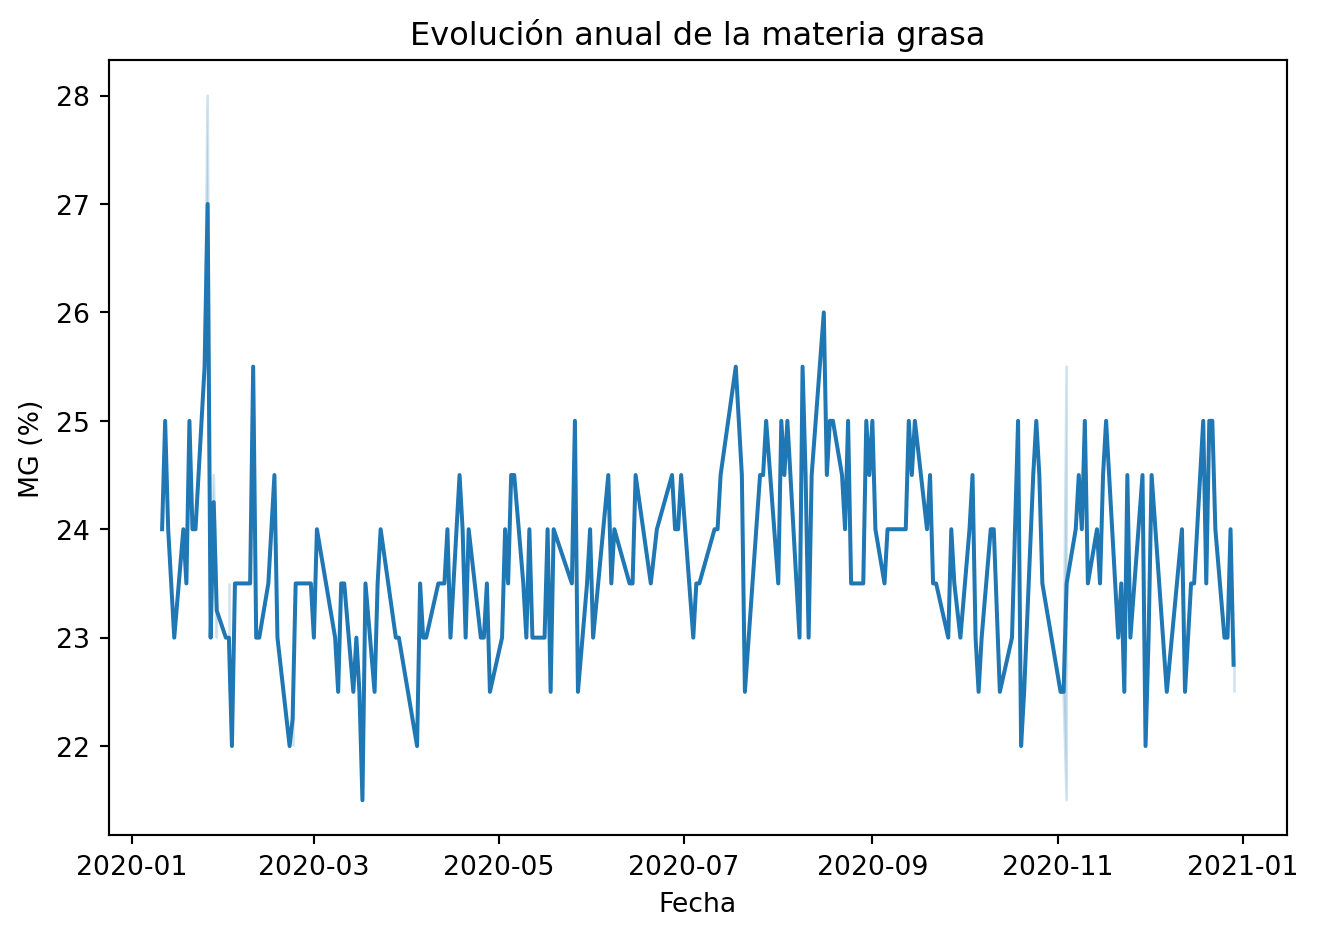

In [11]:
sns.lineplot(data=df, x='fecha', y='mg')
plt.title("Evolución anual de la materia grasa")
plt.xlabel("Fecha")
plt.ylabel("MG (%)")
plt.tight_layout()
plt.show()

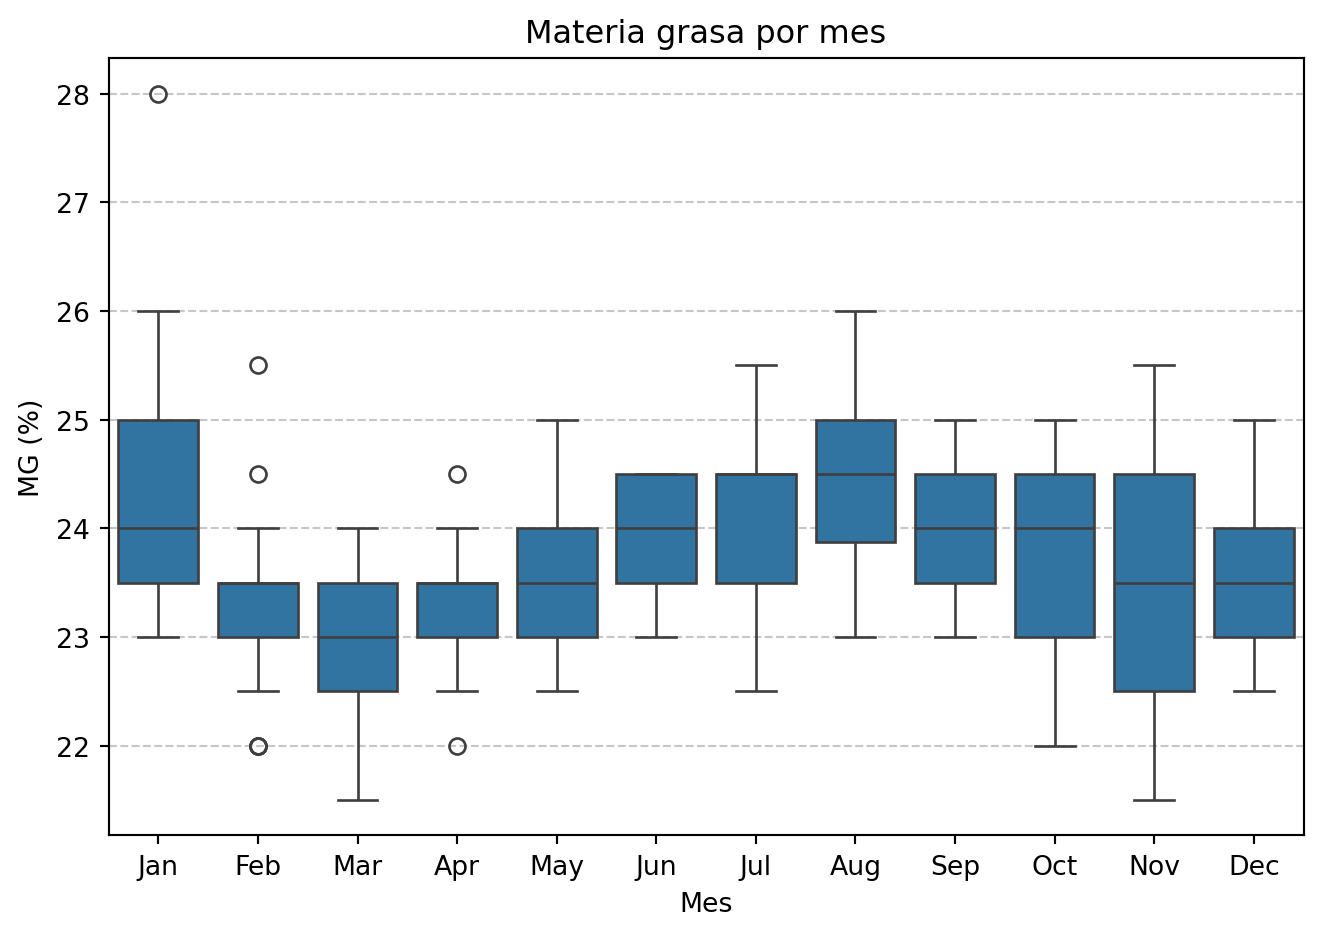

In [12]:
import calendar
df_plot2 = df.copy()
df_plot2['mes_abreviado'] = df_plot2.index.strftime('%b')
meses_orden = [calendar.month_abbr[i] for i in range(1, 13)]
df_plot2['mes_abreviado'] = pd.Categorical(
    df_plot2['mes_abreviado'],
    categories=meses_orden,
    ordered=True
)

sns.boxplot(x='mes_abreviado', y='mg', data=df_plot2)
plt.title("Materia grasa por mes")
plt.xlabel("Mes")
plt.ylabel("MG (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El boxplot mensual de la materia grasa no muestra la misma estacionalidad pronunciada que el extracto seco. El valor de 28% de enero es claramente atípico respecto a su mes, pero el resto del año la materia grasa se mantiene en un rango bastante estable entre 22 y 26%. A partir de febrero se observa una tendencia moderada al alza hasta el verano, que se corrige progresivamente en el segundo semestre.

### Análisis conjunto: gráfico de dispersión `est` vs `mg`

Hasta ahora hemos analizado cada variable por separado. El gráfico de dispersión nos permite ver si existe relación entre el extracto seco y la materia grasa:

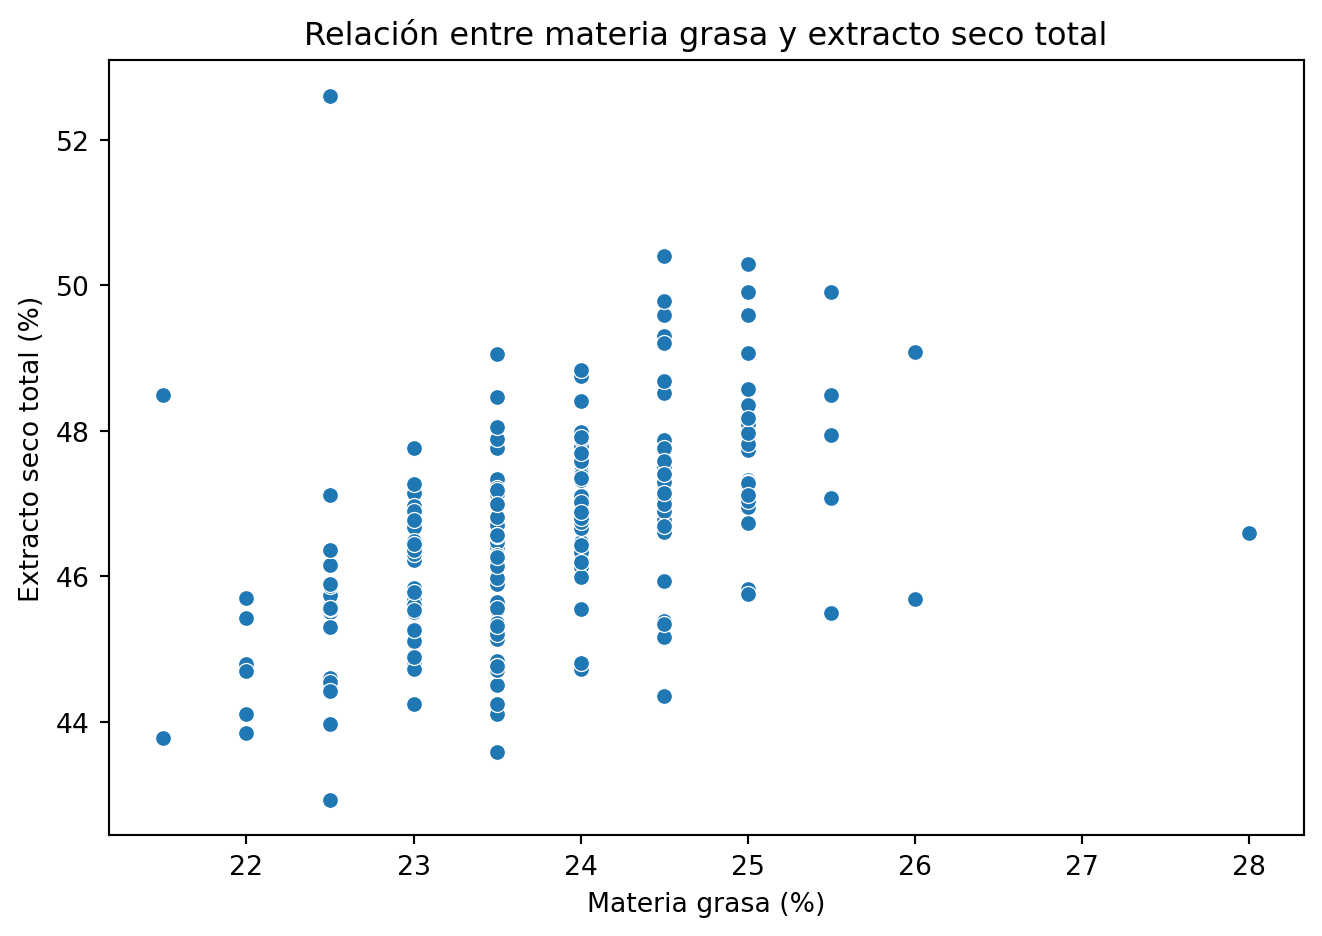

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='mg', y='est')
plt.title("Relación entre materia grasa y extracto seco total")
plt.xlabel("Materia grasa (%)")
plt.ylabel("Extracto seco total (%)")
plt.tight_layout()
plt.show()

La nube de puntos muestra una correlación positiva moderada: en general, cuando la materia grasa sube, el extracto seco también sube. Pero hay tres puntos que se separan claramente del conjunto: son los valores con `est` muy alto (en torno a 50-52%) combinados con `mg` normal o incluso baja. Estos puntos corresponden al período de verano que ya identificamos. El punto aislado con `mg` = 28% y `est` normal también destaca. Estos tres puntos anómalos son los que discutiremos con el equipo en la fase de conclusiones.

Coloreamos por trimestre para ver mejor la estructura estacional con una paleta legible:

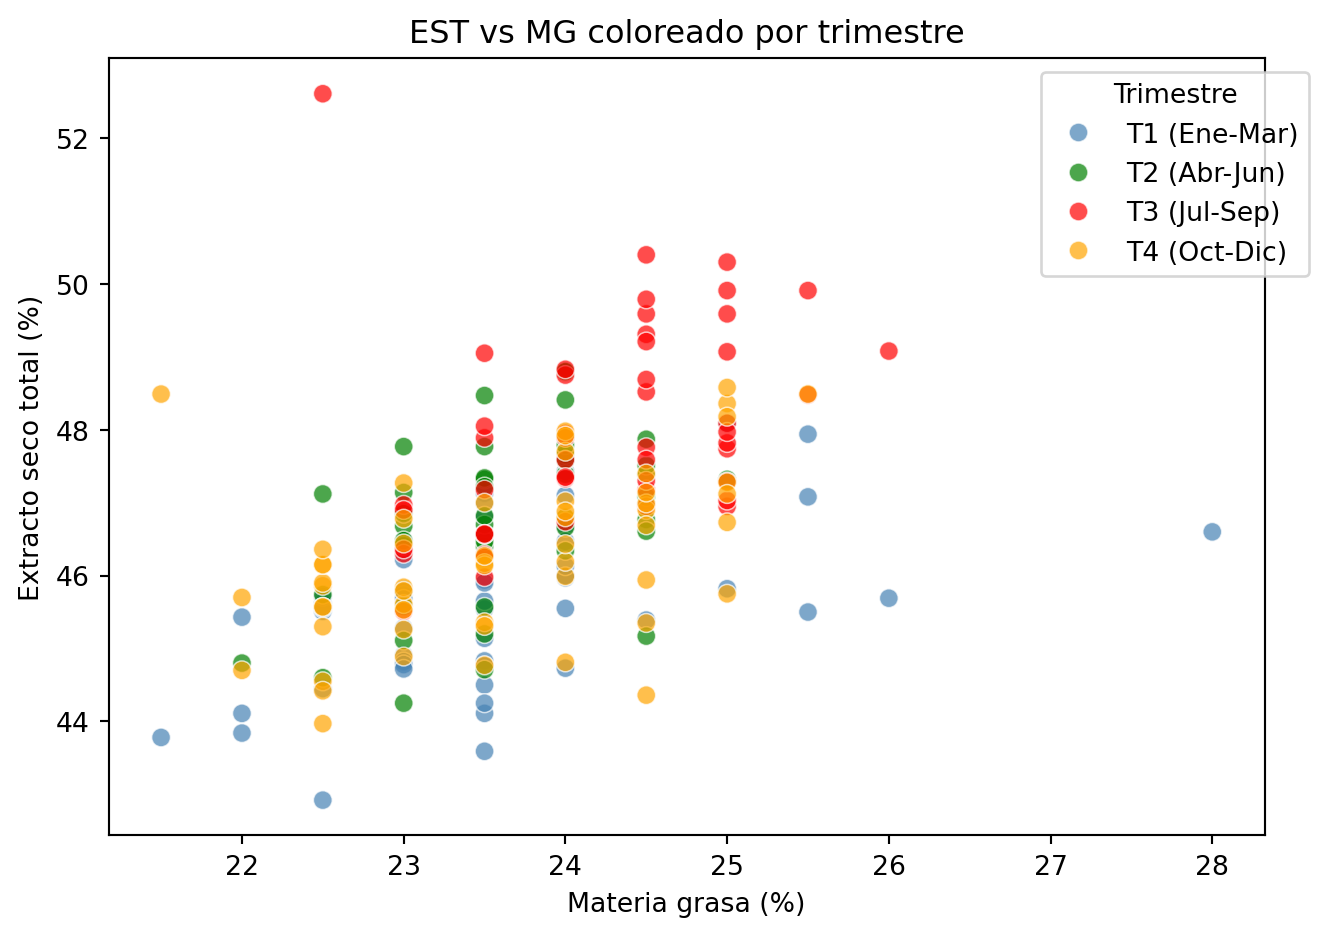

In [14]:
df_plot = df.copy()
df_plot['trimestre'] = df_plot.index.quarter.map(
    {1: 'T1 (Ene-Mar)', 2: 'T2 (Abr-Jun)',
     3: 'T3 (Jul-Sep)', 4: 'T4 (Oct-Dic)'}
)

sns.scatterplot(data=df_plot, x='mg', y='est',
                hue='trimestre',
                palette=['steelblue','green','red','orange'],
                s=50, alpha=0.7)
plt.title("EST vs MG coloreado por trimestre")
plt.xlabel("Materia grasa (%)")
plt.ylabel("Extracto seco total (%)")
plt.legend(title='Trimestre', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Los puntos del tercer trimestre (julio-septiembre) se sitúan claramente en la parte superior del gráfico, confirmando que la desviación de verano afecta a ambas variables simultáneamente, aunque con mayor intensidad en el extracto seco.

### Variable derivada: humedad del queso desnatado (`hqd`)

Como tecnólogos queseros, sabemos que un factor crítico de la textura del queso, y en consecuencia de su calidad, es la humedad del extracto seco desnatado. Este parámetro se calcula a partir del extracto seco y la materia grasa:

$$\text{hqd} = \frac{(100 - \text{est\%})}{(100 - \text{mg\%})} \times 100$$

Creamos la nueva columna y analizamos su evolución:

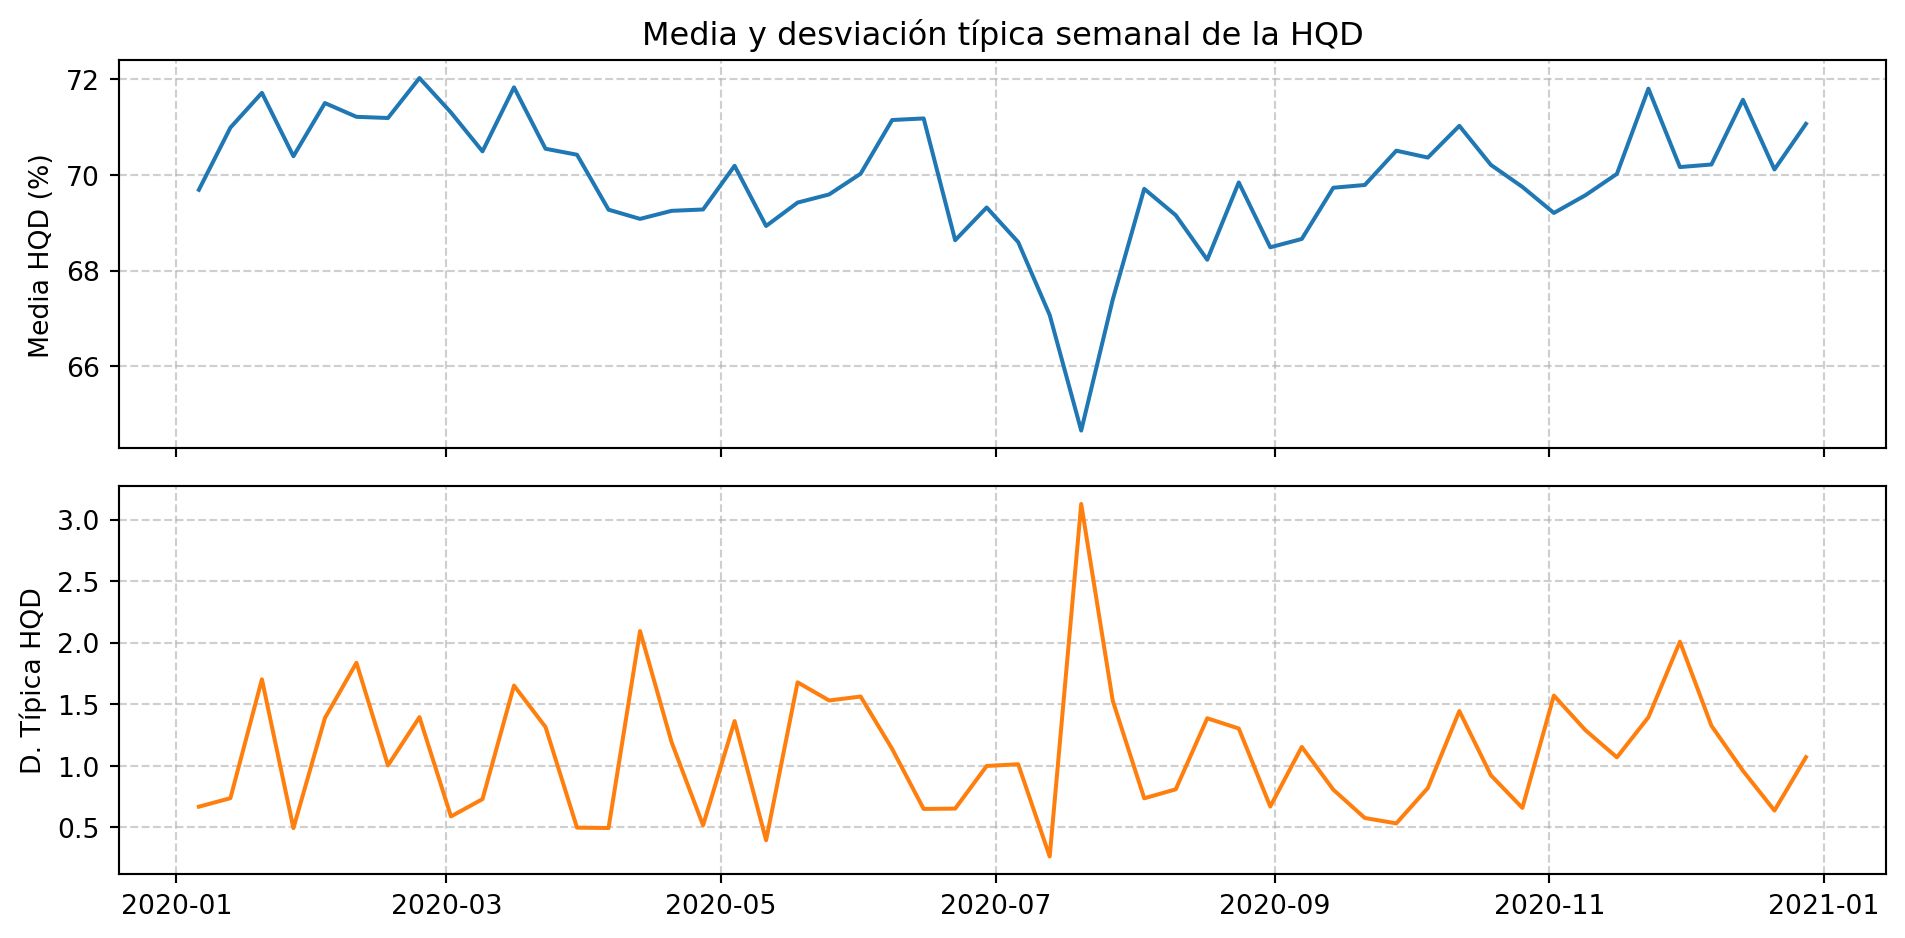

In [15]:
df['hqd'] = ((100 - df['est']) / (100 - df['mg'])) * 100

media_semanal = df["hqd"].resample(
    'W-MON', label='left', closed='left').mean()
dt_semanal = df["hqd"].resample(
    'W-MON', label='left', closed='left').std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax1.plot(media_semanal, color='tab:blue')
ax1.set_title("Media y desviación típica semanal de la HQD")
ax1.set_ylabel("Media HQD (%)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.tick_params(labelbottom=False)

ax2.plot(dt_semanal, color='tab:orange')
ax2.set_ylabel("D. Típica HQD")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

La `hqd` muestra el patrón más revelador de todo el análisis. El fabricante mantiene la humedad razonablemente estable en torno al 70-71% durante la primera mitad del año, con algunos ajustes menores. En julio se produce una caída brusca hasta valores de 61-63%, la peor semana corresponde al 21 de julio con una `hqd` de 61,15%. Esta desviación de casi 10 puntos es muy significativa para la textura del camembert y explica las reclamaciones de queso demasiado seco que se recibieron en ese período.

## Análisis de otras variables

### pH

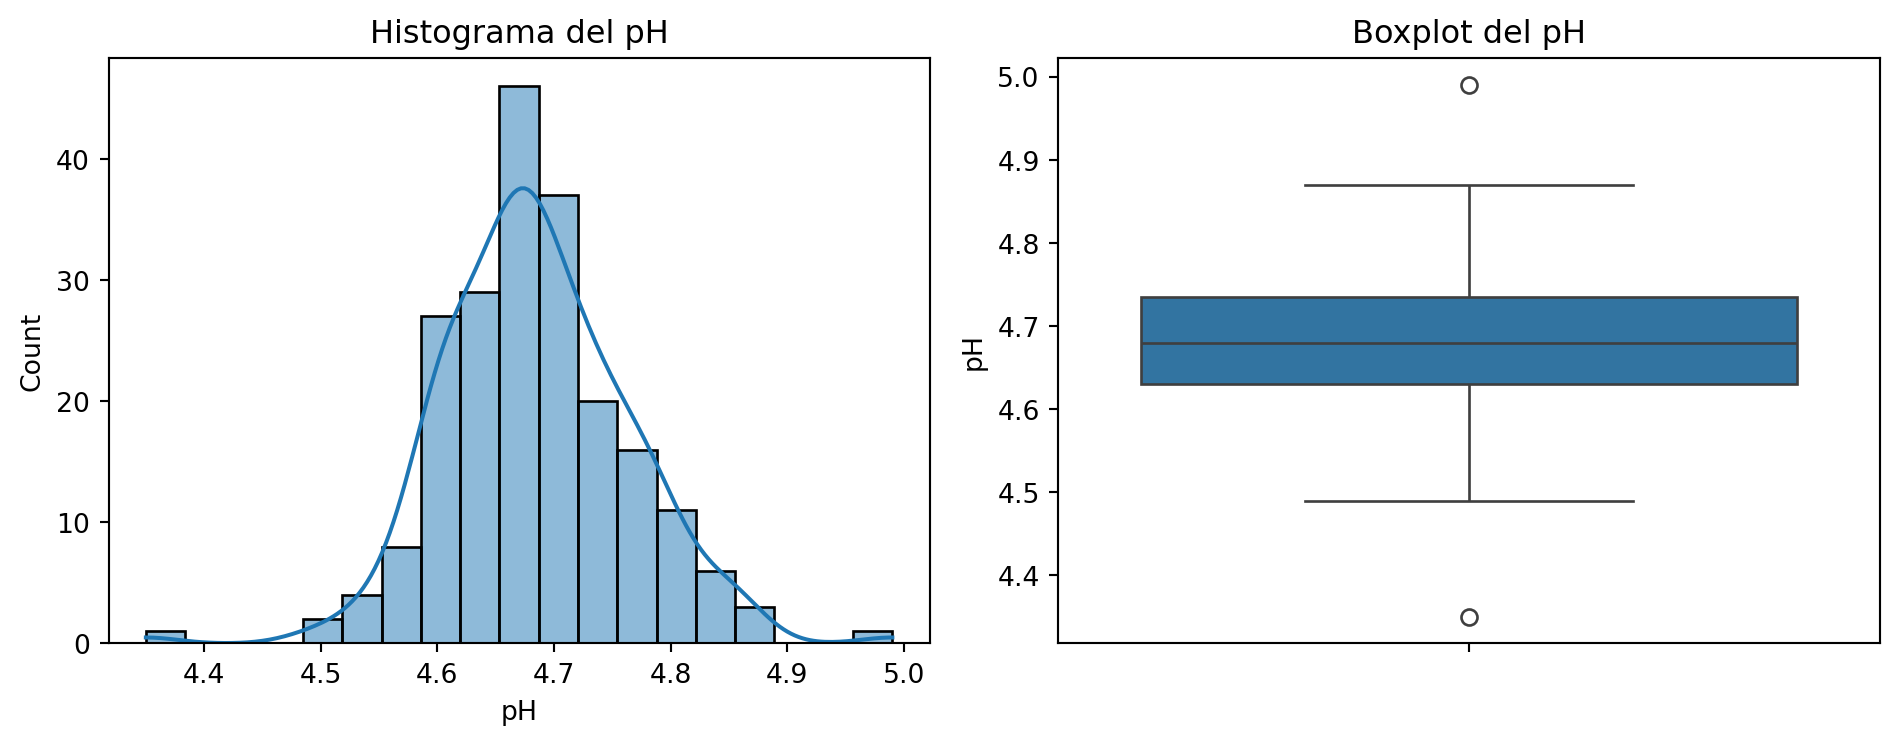

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['ph'], kde=True, ax=ax1)
ax1.set_title("Histograma del pH")
ax1.set_xlabel("pH")

sns.boxplot(y=df['ph'], ax=ax2)
ax2.set_title("Boxplot del pH")
ax2.set_ylabel("pH")

plt.tight_layout()
plt.show()

El pH muestra una distribución aproximadamente simétrica centrada en 4,68, con un rango habitual entre 4,5 y 4,9. El boxplot señala dos valores atípicos: el mínimo de 4,35 (18 de abril) y el máximo de 4,99 (25 de enero). El valor de 4,35 merece atención porque se aleja bastante del rango habitual; puede indicar una acidificación excesiva en esa fabricación o un error analítico. El pH y los cloruros se proponen como ejercicio de análisis completo al final del capítulo.

### Cloruros

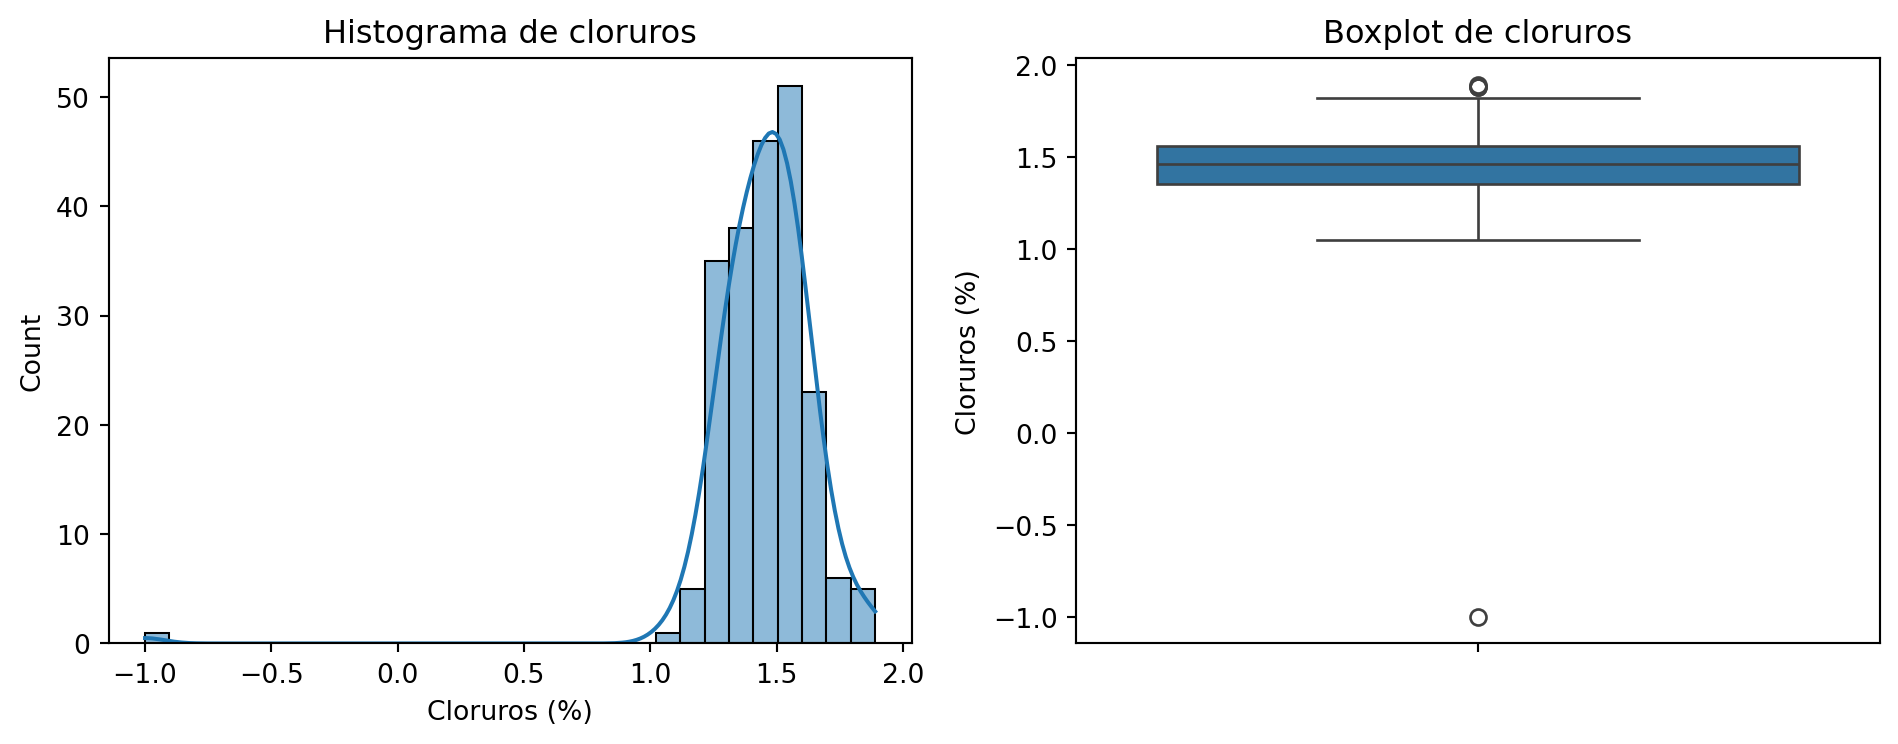

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['cloruros'], kde=True, ax=ax1)
ax1.set_title("Histograma de cloruros")
ax1.set_xlabel("Cloruros (%)")

sns.boxplot(y=df['cloruros'], ax=ax2)
ax2.set_title("Boxplot de cloruros")
ax2.set_ylabel("Cloruros (%)")

plt.tight_layout()
plt.show()

El histograma de cloruros muestra una distribución aproximadamente simétrica en torno a 1,45-1,50%, con un rango habitual entre 1,1 y 1,9%. El boxplot señala un único valor atípico muy llamativo: -1%, registrado el 11 de febrero. Un contenido en cloruros negativo es físicamente imposible, por lo que se trata sin duda de un error de entrada de datos: probablemente se introdujo el valor con el signo menos por error. Este valor debe tratarse como un dato ausente (`NaN`) antes de cualquier análisis posterior.

### Coliformes: un ejemplo de distribución asimétrica positiva

Los recuentos de bacterias coliformes merecen un análisis específico porque su distribución es radicalmente distinta a la del resto de variables. Antes de hacer el histograma, veamos los estadísticos básicos:

In [18]:
print(df['coliformes'].describe().round(1))
print(f"\nValores = 0: {(df['coliformes']==0).sum()}")
print(f"Valores > 1000: {(df['coliformes']>1000).sum()}")
print(f"Valores > 5000: {(df['coliformes']>5000).sum()}")

count      210.0
mean       650.9
std       2194.1
min          0.0
25%          0.0
50%         10.0
75%        190.0
max      20200.0
Name: coliformes, dtype: float64

Valores = 0: 89
Valores > 1000: 28
Valores > 5000: 9


La mediana es 10 ufc/g pero la media es 651 ufc/g, casi 65 veces mayor. El 42% de los valores son exactamente cero, y hay 9 valores por encima de 5.000 ufc/g, con un máximo de 20.200 ufc/g el 12 de agosto. Esta diferencia enorme entre la mediana y la media es la señal característica de una distribución muy asimétrica positiva.

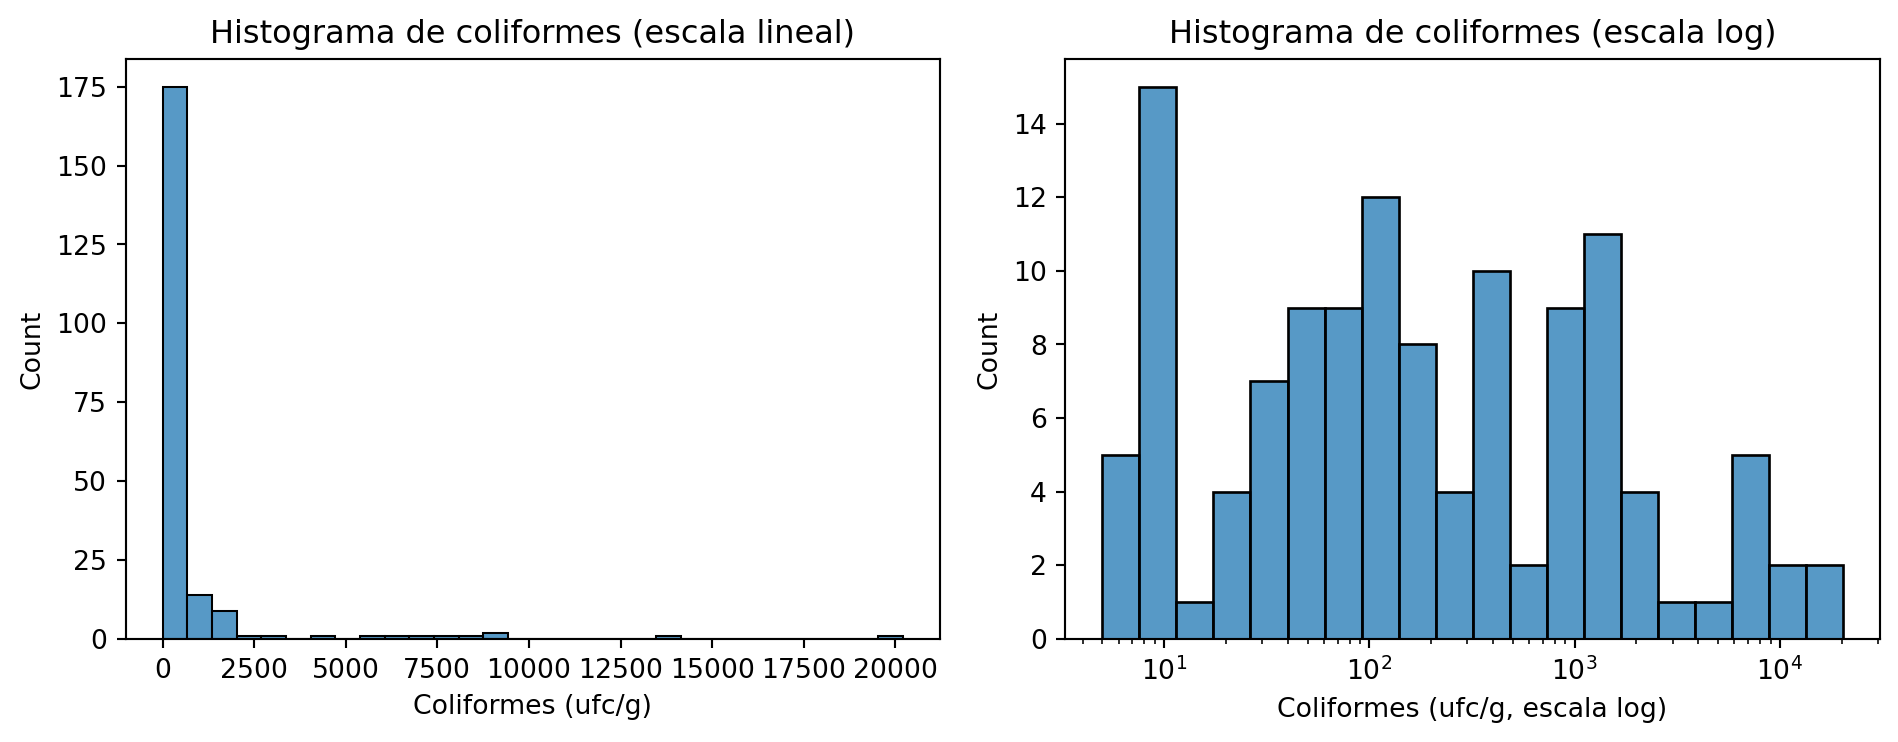

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['coliformes'].dropna(), bins=30, ax=ax1)
ax1.set_title("Histograma de coliformes (escala lineal)")
ax1.set_xlabel("Coliformes (ufc/g)")

# escala logarítmica para ver mejor la distribución
col_nozero = df['coliformes'][df['coliformes'] > 0].dropna()
sns.histplot(col_nozero, log_scale=True, bins=20, ax=ax2)
ax2.set_title("Histograma de coliformes (escala log)")
ax2.set_xlabel("Coliformes (ufc/g, escala log)")

plt.tight_layout()
plt.show()

En escala lineal, el histograma muestra una barra altísima en los valores bajos y una larga cola hacia la derecha: es la asimetría positiva extrema que veíamos en el capítulo 6 con los goles por partido, pero mucho más pronunciada. En escala logarítmica la distribución se hace visible con más detalle: la mayoría de los recuentos positivos están entre 10 y 1.000 ufc/g, y los valores muy altos son escasos pero existen.

Este efecto es el mismo que el de un peso situado lejos del fulcro de una balanza: aunque sea un solo valor extremo, su distancia al centro multiplica su influencia sobre la media de forma desproporcionada. Por eso en variables con distribución muy asimétrica la media no es un buen descriptor del conjunto.

Veamos la distribución mensual mediante un boxplot con los puntos individuales superpuestos. Como el logaritmo de cero no está definido, excluimos las muestras con recuento nulo: estas muestras no aportan información sobre la magnitud de la contaminación, y su inclusión aplastaría el gráfico hacia el cero haciendo ilegible el resto de la distribución. El alumno debe tener en cuenta que los meses con muchos ceros tendrán menos puntos representados, lo que también es información relevante sobre la higiene del proceso.

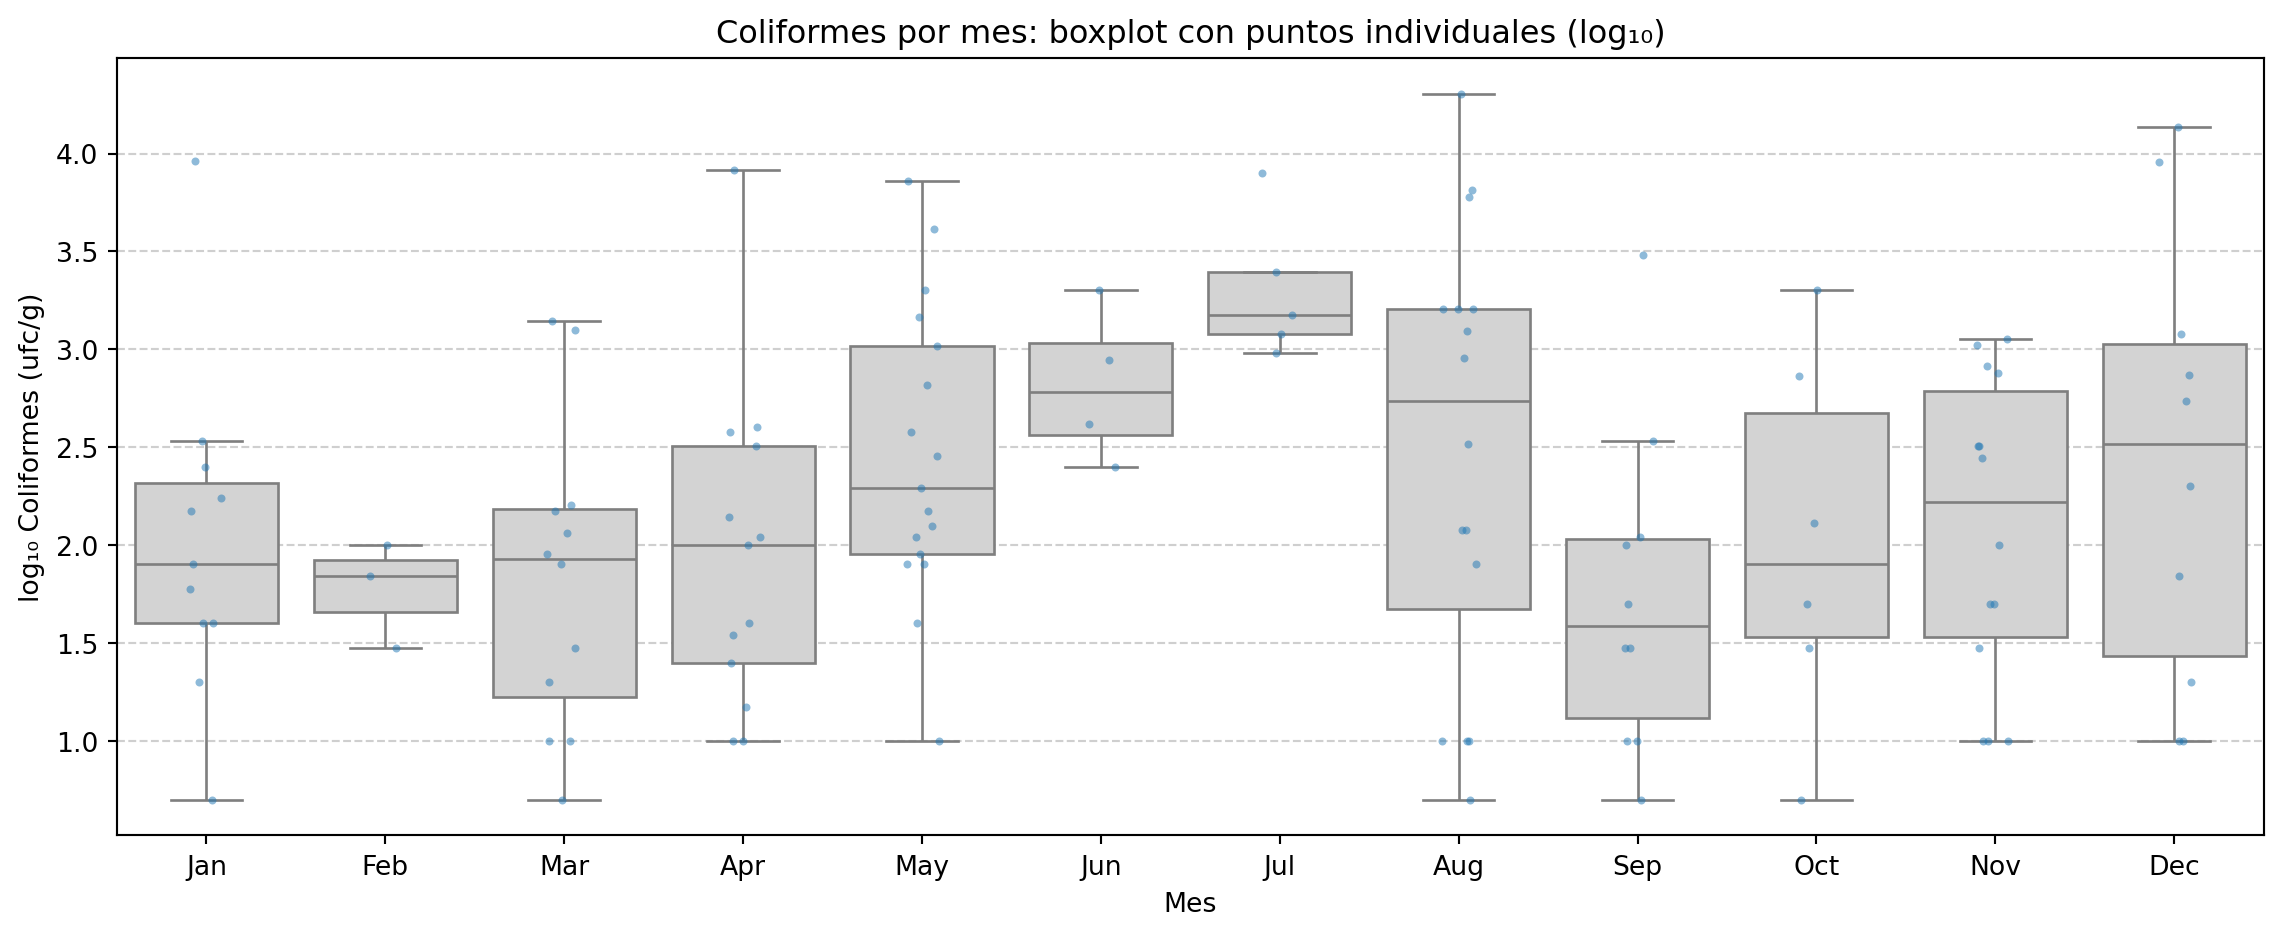

In [20]:
import calendar
import numpy as np
df = df.reset_index(drop=True)
df_plot_col = df[df['coliformes'] > 0].copy()
df_plot_col['log_coliformes'] = np.log10(df_plot_col['coliformes'])
df_plot_col['mes_abreviado'] = df_plot_col['fecha'].dt.strftime('%b')
meses_orden = [calendar.month_abbr[i] for i in range(1, 13)]
df_plot_col['mes_abreviado'] = pd.Categorical(
    df_plot_col['mes_abreviado'],
    categories=meses_orden,
    ordered=True
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_plot_col, x='mes_abreviado', y='log_coliformes',
            fliersize=0, color='lightgray', ax=ax)
sns.stripplot(data=df_plot_col, x='mes_abreviado', y='log_coliformes',
              jitter=True, size=3, alpha=0.5, ax=ax)
ax.set_title("Coliformes por mes: boxplot con puntos individuales (log₁₀)")
ax.set_xlabel("Mes")
ax.set_ylabel("log₁₀ Coliformes (ufc/g)")
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

El gráfico muestra picos puntuales dispersos a lo largo del año, sin un patrón estacional claro y sostenido. La mediana de los valores se incrementa desde abril hasta julio, donde hay un máximo que parece significativo, ya que la caja del boxplot no se solapa con las anteriores. De manera coherente con la información agregada, los valores individuales se concentran en primavera y verano, coincidiendo con las temperaturas ambientales más altas y el período de sustituciones de personal en vacaciones. El valor máximo de 20.200 ufc/g del 12 de agosto es el más llamativo. En invierno los recuentos son en general más bajos y más homogéneos.

## Conclusiones y plan de acción

### Análisis de resultados

Una vez explorados los datos de todas las variables, podemos formular las hipótesis de trabajo:

1. A principio de año hay un valor anómalo de materia grasa (28%, 26 de enero) que puede haberse debido a un error en la estandarización coincidiendo con una leche de invierno más rica en grasa. A pesar de esto, la `hqd` se mantuvo estable, lo que indica que el fabricante corrigió el extracto seco para compensar.

2. Hay un claro error de entrada en cloruros: el valor -1% del 11 de febrero es físicamente imposible y debe tratarse como dato ausente.

3. El pH de 4,35 del 18 de abril se aleja significativamente del rango habitual y merece verificación con el laboratorio.

4. La desviación más importante del año es el aumento sostenido del extracto seco en julio, con un máximo de 52,61% el 21 de julio, que produjo una caída de la `hqd` hasta 61,15%. Esta bajada de casi 10 puntos respecto al objetivo habitual de 70-71% es la causa directa de las reclamaciones por queso demasiado seco recibidas en ese período.

5. Los recuentos de coliformes no muestran una tendencia estacional clara, pero los valores más altos se concentran en verano, coincidiendo con el período de aumento de temperatura ambiente que incrementa el riesgo de crecimiento bacteriano. Hay que tener en cuenta también las sustituciones de personal en vacaciones, que pueden añadir más variabilidad a los resultados analíticos como consecuencia de la menor experiencia analítica de las personas temporales.

6. Hay tres puntos en el gráfico de dispersión `est` vs `mg` que se separan claramente del conjunto: son candidatos a revisión analítica antes de repetir el análisis definitivo.

### Comunicar: discusión en equipo

Hemos presentado el análisis al equipo de fabricación, laboratorio y producción. Las conclusiones de la reunión son:

- El responsable de fabricación confirma que hace ajustes estacionales en la estandarización a lo largo del año para mantener la `hqd` constante. En verano, debido a las temperaturas más altas en las zonas de distribución, la práctica habitual es bajar moderadamente la `hqd` para evitar una proteólisis excesiva durante el ciclo de comercialización.
- Este año el quesero fue sustituido durante vacaciones por una persona con menos experiencia, que forzó el extracto seco más de lo debido. Las reclamaciones de los clientes por queso demasiado seco en agosto confirman esta hipótesis.
- El laboratorio confirma que los tres valores anómalos del gráfico de dispersión pueden corresponder a análisis incorrectos, y recomienda no tenerlos en cuenta en el análisis definitivo.
- El valor negativo de cloruros es claramente un error de entrada de datos.

### Plan de acción

A la vista del análisis, el equipo propone las siguientes acciones:

1. Revisar diariamente la composición de la leche para evitar errores de estandarización, especialmente en los cambios de estación.
2. Mejorar la formación de las personas que cubren los puntos clave (quesero, analistas) en períodos de vacaciones o enfermedad, anticipando los ciclos de formación.
3. Revisar los métodos analíticos con el laboratorio y valorar un estudio de precisión, incluyendo la variabilidad entre analistas.
4. Establecer un sistema de seguimiento ágil de la `hqd` en tiempo real, para detectar desviaciones antes de que afecten al producto en el punto de venta.
5. Valorar si los problemas de proteólisis en verano son generales o se concentran en clientes específicos con peores condiciones de conservación, ajustando el objetivo de `hqd` de verano de forma más precisa.
6. Repetir el análisis eliminando los valores erróneos identificados, para verificar que las conclusiones se mantienen.

Dado que la capacidad del equipo es limitada, en sucesivas reuniones se priorizarán las acciones de mayor impacto y se establecerán indicadores que se publicarán semanalmente en paneles de planta.

## Resumen del capítulo

En este capítulo hemos aplicado el flujo de trabajo completo del análisis de datos a una fabricación real de queso camembert. El análisis variable a variable ha permitido identificar errores de entrada (el valor negativo de cloruros), valores atípicos que requieren verificación (el pH de 4,35 en abril, el valor de materia grasa de 28% en enero) y la desviación estacional más importante del año: el aumento sostenido del extracto seco en julio, que produjo una caída de la humedad del queso desnatado de casi 10 puntos y originó reclamaciones de los clientes.

La serie temporal ha sido la herramienta clave para interpretar correctamente lo que el histograma mostraba como una simple distribución asimétrica: lo que parecía un valor atípico aislado era en realidad parte de una desviación estacional sostenida durante varias semanas. El análisis de los coliformes ha ilustrado con datos reales el concepto de distribución asimétrica positiva extrema, característica de los recuentos microbiológicos, y la razón por la que la mediana es más informativa que la media en este tipo de variables.

El capítulo concluye con una fase de comunicación en equipo que transforma el análisis estadístico en hipótesis de trabajo contrastadas con el conocimiento tecnológico y en un plan de acción priorizado. En el capítulo siguiente nos enfrentaremos al análisis de las entradas de leche en una gran fábrica de queso.

## Ejercicios propuestos

### Ejercicio 1: análisis completo de pH y cloruros

Realiza el análisis exploratorio completo de las variables `ph` y `cloruros`, siguiendo la misma metodología aplicada a `est` y `mg` en este capítulo:

- Histograma y boxplot
- Serie temporal anual
- Boxplot mensual
- Interpretación de los valores atípicos detectados

Para los cloruros, filtra previamente el valor negativo convirtiéndolo en `NaN` antes de representar los gráficos.

### Ejercicio 2: repetir el análisis sin los valores erróneos

El laboratorio ha confirmado que los tres puntos anómalos del gráfico de dispersión `est` vs `mg` son probablemente errores analíticos. Utiliza Python o R para filtrarlos y repite el análisis completo con el dataset corregido. ¿Cambian las conclusiones?

Como referencia, los criterios de filtrado son: valores de `mg` superiores a 27%, valores de `est` superiores a 52%, y valores con `mg` inferior a 22% y `est` superior a 48% de forma simultánea.

### Ejercicio 3 (avanzado): transformación logarítmica de coliformes

Los recuentos microbiológicos se analizan habitualmente en escala logarítmica. Crea una nueva columna `log_coliformes` con el logaritmo en base 10 de los recuentos (excluyendo los ceros), y compara el histograma de la escala lineal con el de la escala logarítmica. ¿Cómo cambia la forma de la distribución? ¿Qué valores de la escala logarítmica corresponden a los límites microbiológicos habituales en queso camembert?